## **IMPORT LIBRARY**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Model
import lightgbm as lgb

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

## **SETUP FILE**

In [3]:
df = pd.read_csv("dataset/train.csv")
dft = pd.read_csv("dataset/test.csv")
baris, kolom = df.shape
print(f'Baris: {baris}, Kolom: {kolom}')
target = 'property_organic_content'
df.head()

Baris: 11210, Kolom: 52


,sample_id,source_id,has_band_A_spectrum,has_band_B_spectrum,sampling_strategy,sampling_depth_cm,geo_zone_macro,geo_zone_micro,geo_zone_meso,land_cover_type,...,spectral_band_B_PC_6,spectral_band_B_PC_7,spectral_band_B_PC_8,spectral_band_B_PC_9,spectral_band_B_PC_10,spectral_band_B_PC_11,spectral_band_B_PC_12,spectral_band_B_PC_13,spectral_band_B_PC_14,spectral_band_B_PC_15
0,train_00001,Source_01,YES,NO,Auger,0-20,SE,Unknown,State_01,Seasonal Semideciduous Forest,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,train_00002,Source_10,YES,NO,Auger,0-20,MW,Loc_011,State_10,Savannah,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,train_00003,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,train_00004,Source_02,YES,NO,Auger,0-20,N,Unknown,State_07,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,train_00005,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **HANDLE MISSING VALUES**

In [4]:
missing_count = df.isnull().sum()
missing_percentage = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percentage': missing_percentage
})

missing_df = missing_df[missing_df['missing_count'] > 0]
print(missing_df.sort_values(by='missing_percentage', ascending=False))

                          missing_count  missing_percentage
cation_Na                         10808           96.413916
spectral_band_B_PC_7               9516           84.888492
spectral_band_B_PC_5               9516           84.888492
spectral_band_B_PC_6               9516           84.888492
spectral_band_B_PC_4               9516           84.888492
spectral_band_B_PC_3               9516           84.888492
spectral_band_B_PC_2               9516           84.888492
spectral_band_B_PC_1               9516           84.888492
spectral_band_B_PC_12              9516           84.888492
spectral_band_B_PC_9               9516           84.888492
spectral_band_B_PC_10              9516           84.888492
spectral_band_B_PC_11              9516           84.888492
spectral_band_B_PC_14              9516           84.888492
spectral_band_B_PC_13              9516           84.888492
spectral_band_B_PC_15              9516           84.888492
spectral_band_B_PC_8               9516 

- cation Na hilang 96.4 % --> Drop aja
- spectral b rata hilang 84 % --> lihat isinya dulu
- latitude, longitude hilang 74% ++ --> impute?
- property_acidity_index ilang 74% ++ juga --> impute?

### **Drop cation Na**

In [5]:
df = df.drop(columns= 'cation_Na')
dft = dft.drop(columns= 'cation_Na')

print('cation_Na ilang')

cation_Na ilang


### **EDA Spectral B**

In [6]:
spectral_b_cols = []
for i in range(1,16):
    spektral = f'spectral_band_B_PC_{i}'
    spectral_b_cols.append(spektral)

spectral_b_cols_df = df[spectral_b_cols]

apakah saat salah satu spectral band b kosong, maka semua ikut kosong?

In [7]:
for i in range(1,16):
    ratakosong = df[spectral_b_cols].isnull().all(axis=1).equals(df[f'spectral_band_B_PC_{i}'].isnull())
    print(i, ratakosong)

1 True
2 True
3 True
4 True
5 True
6 True
7 True
8 True
9 True
10 True
11 True
12 True
13 True
14 True
15 True


True, berarti semua kolom missing barengan. artinya,
- salah satu data spectral b ga ada, makasemua data spectral b ga ada
- satu sumber (source_id) gapunya data spectral b

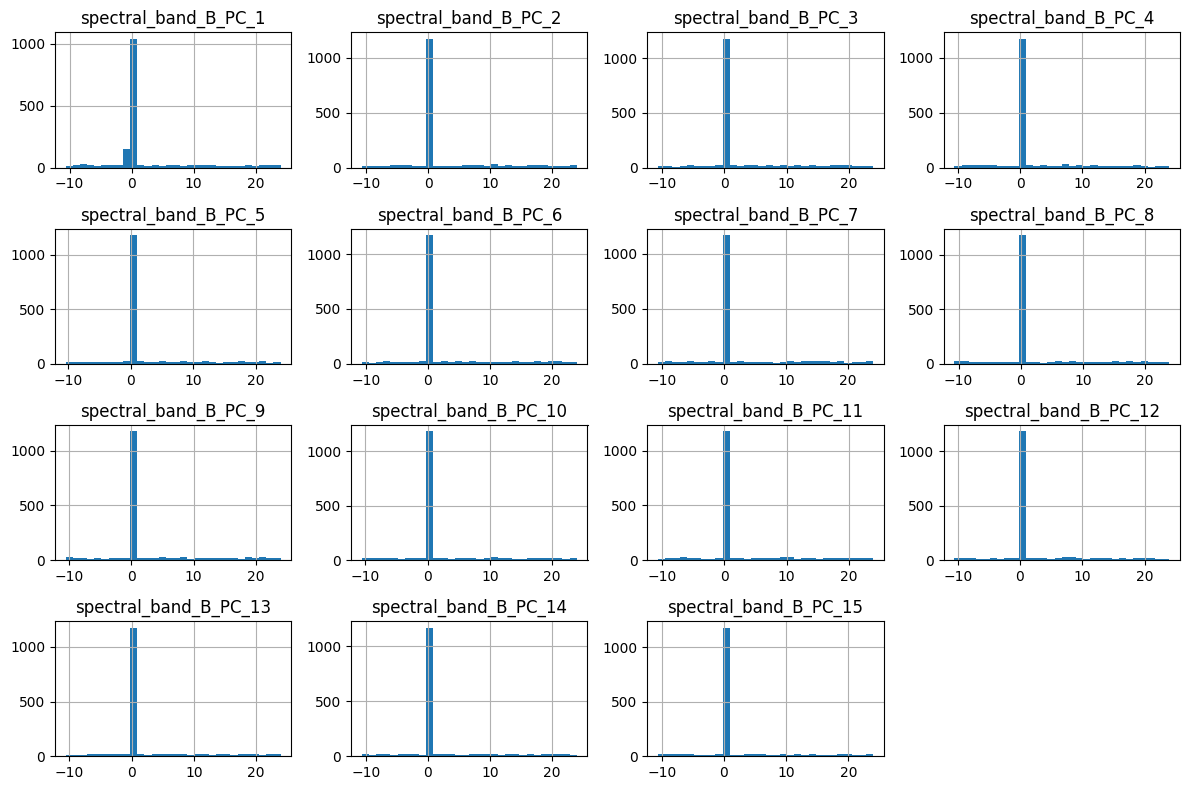

In [8]:
spectral_b_cols_df.dropna().hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

walaupun disitu dominan 0, tapi data yang hilang juga banyak (84%). maka ada 2 opsi, 
- biarin NaN dan tambahin flag aja
- flag + impute

coba2 aja

In [9]:
#FLAG
df['spectral_missing'] = df[spectral_b_cols].isna().all(axis=1).astype(int)
dft['spectral_missing'] = dft[spectral_b_cols].isna().all(axis=1).astype(int)

#IMPUTE
for col in spectral_b_cols:
    df[col] = df[col].fillna(df[col].median())
    dft[col] = dft[col].fillna(df[col].median())

### **EDA Latitude, Longitude**

In [10]:
#Flag
df['geo_missing'] = df[['latitude', 'longitude']].isna().all(axis=1).astype(int)
dft['geo_missing'] = dft[['latitude', 'longitude']].isna().all(axis=1).astype(int)

df.groupby('geo_missing')[target].mean()

geo_missing
0    34.586032
1    34.022336
Name: property_organic_content, dtype: float64

### **EDA keasaman tanah**

In [11]:
df.groupby('parent_rock_type')['property_acidity_index'].agg(['count', 'size'])
df.groupby('parent_rock_type')['property_acidity_index'].agg(
    total='size',
    filled='count'
).assign(
    fill_rate=lambda x: x['filled'] / x['total']
)

dft.groupby('parent_rock_type')['property_acidity_index'].agg(['count', 'size'])
dft.groupby('parent_rock_type')['property_acidity_index'].agg(
    total='size',
    filled='count'
).assign(
    fill_rate=lambda x: x['filled'] / x['total']
)

,total,filled,fill_rate
parent_rock_type,,,
Igneous Rock,1280,424,0.331250
Metamorphic Rock,122,17,0.139344
Sedimentary Rock,857,213,0.248541
Unknown,411,47,0.114355


Bisa dilihat bahwa untuk satu tipe batu yang sama, tidak selalu memiliki data property_acidity_index. Maka, Coba
1. kasih flag + impute median groupby tipe batu induk
2. kasih flag aja

In [12]:
#Flag
df['acidity_missing'] = df['property_acidity_index'].isna().astype(int)
dft['acidity_missing'] = dft['property_acidity_index'].isna().astype(int)

#Impute
df['property_acidity_index'] = df.groupby('parent_rock_type')['property_acidity_index']\
    .transform(lambda x: x.fillna(x.median()))
dft['property_acidity_index'] = dft.groupby('parent_rock_type')['property_acidity_index']\
    .transform(lambda x: x.fillna(x.median()))

### **Tambahan : Flag buat biome, parent rock type, land cover type**

In [13]:
df['rock_missing'] = (df['parent_rock_type'] == 'Unknown').astype(int)
df['biome_missing'] = (df['biome'] == 'Unknown').astype(int)
df['land_missing'] = (df['land_cover_type'] == 'Unknown').astype(int)
dft['rock_missing'] = (dft['parent_rock_type'] == 'Unknown').astype(int)
dft['biome_missing'] = (dft['biome'] == 'Unknown').astype(int)
dft['land_missing'] = (dft['land_cover_type'] == 'Unknown').astype(int)

## **TRAIN**

In [14]:
cat_cols = df.select_dtypes(exclude='number').columns
df[cat_cols] = df[cat_cols].astype('category')
dft[cat_cols] = dft[cat_cols].astype('category')
df.dtypes

sample_id                   category
source_id                   category
has_band_A_spectrum         category
has_band_B_spectrum         category
sampling_strategy           category
sampling_depth_cm           category
geo_zone_macro              category
geo_zone_micro              category
geo_zone_meso               category
land_cover_type             category
biome                       category
parent_rock_type            category
property_particle_coarse     float64
property_particle_fine       float64
property_organic_content     float64
property_acidity_index       float64
cation_Ca                    float64
cation_Mg                    float64
cation_exchange_capacity     float64
latitude                     float64
longitude                    float64
spectral_band_A_PC_1         float64
spectral_band_A_PC_2         float64
spectral_band_A_PC_3         float64
spectral_band_A_PC_4         float64
spectral_band_A_PC_5         float64
spectral_band_A_PC_6         float64
s

In [15]:
X = df.drop(columns = target)
Xt = dft
y = df[target]
X.head()

,sample_id,source_id,has_band_A_spectrum,has_band_B_spectrum,sampling_strategy,sampling_depth_cm,geo_zone_macro,geo_zone_micro,geo_zone_meso,land_cover_type,...,spectral_band_B_PC_12,spectral_band_B_PC_13,spectral_band_B_PC_14,spectral_band_B_PC_15,spectral_missing,geo_missing,acidity_missing,rock_missing,biome_missing,land_missing
0,train_00001,Source_01,YES,NO,Auger,0-20,SE,Unknown,State_01,Seasonal Semideciduous Forest,...,0.000681,0.001791,0.001155,0.000902,1,1,1,0,0,0
1,train_00002,Source_10,YES,NO,Auger,0-20,MW,Loc_011,State_10,Savannah,...,0.000681,0.001791,0.001155,0.000902,1,0,0,0,0,0
2,train_00003,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,...,0.000681,0.001791,0.001155,0.000902,1,1,1,1,1,1
3,train_00004,Source_02,YES,NO,Auger,0-20,N,Unknown,State_07,Unknown,...,0.000681,0.001791,0.001155,0.000902,1,1,0,0,0,1
4,train_00005,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,...,0.000681,0.001791,0.001155,0.000902,1,1,1,1,1,1


In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_rmse = []
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'verbose': -1,
    'random_state': 42
}

oof_pred = np.zeros(len(X))
test_pred = np.zeros(len(Xt))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Fold {fold+1}")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val)

    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[train_data, val_data],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=100)
        ]
    )
    oof_pred[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    test_pred += model.predict(Xt) / kf.n_splits
    rmse = np.sqrt(mean_squared_error(y_val, oof_pred[val_idx]))
    fold_rmse.append(rmse)

np.mean(fold_rmse)

Fold 1
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 8.99258	valid's rmse: 11.302
[200]	train's rmse: 7.37624	valid's rmse: 11.0586
[300]	train's rmse: 6.47402	valid's rmse: 10.9741
[400]	train's rmse: 5.76375	valid's rmse: 10.9291
[500]	train's rmse: 5.17984	valid's rmse: 10.879
[600]	train's rmse: 4.70377	valid's rmse: 10.8646
[700]	train's rmse: 4.28601	valid's rmse: 10.8419
[800]	train's rmse: 3.90144	valid's rmse: 10.8208
Early stopping, best iteration is:
[796]	train's rmse: 3.91671	valid's rmse: 10.8192
Fold 2
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 9.01416	valid's rmse: 11.5012
[200]	train's rmse: 7.42258	valid's rmse: 11.197
[300]	train's rmse: 6.49886	valid's rmse: 11.127
[400]	train's rmse: 5.78564	valid's rmse: 11.0802
[500]	train's rmse: 5.20399	valid's rmse: 11.0567
[600]	train's rmse: 4.70166	valid's rmse: 11.0476
[700]	train's rmse: 4.25915	valid's rmse: 11.043
Early stopping, best iteration is:

np.float64(11.419946825730799)

In [17]:
rmse = np.sqrt(mean_squared_error(y, oof_pred))
print("OOF RMSE:", rmse)

OOF RMSE: 11.436939660985386


In [18]:
# y_pred = model.predict(Xt)


In [19]:
# submission
submission = pd.DataFrame({
    'sample_id': dft['sample_id'],
    'property_organic_content': test_pred
})

submission.to_csv('test2.csv', index=False)

---
## **RESEARCH QUESTIONS**
*(jawaban di bawah disusun berdasarkan pipeline preprocessing & model di atas — drop cation_Na, flag+impute spectral B, flag+impute acidity, dan LightGBM 5-fold CV)*

### **No. 1 — Urgensi prediksi kandungan organik tanah**

Iya, ini mendesak. Dua alasan utama:

**Efisiensi biaya operasional.** Uji kandungan organik tanah secara konvensional (lab basah, metode Walkley-Black, dsb) itu mahal dan lama. Butuh ambil sampel fisik, kirim ke lab, nunggu hasil. Kalau bisa diprediksi dari data spektral (yang notabene jauh lebih murah/cepat diambil, contohnya scanning langsung di lapangan) + data geografis yang sudah tersedia, biaya per titik sampel turun drastis dan bisa scale ke jutaan hektar lahan tanpa nunggu lab.

**Manajemen lahan berkelanjutan & kebijakan pangan.** Kandungan organik tanah itu proxy kesuburan dan kapasitas penyimpanan karbon tanah. Kalau pemerintah/perusahaan agri bisa memetakan ini secara cepat dan murah di skala luas (seperti lewat dataset ini yang nyebar di banyak `geo_zone_macro` di Brazil), keputusan soal rotasi tanam, dosis pupuk, atau program restorasi lahan terdegradasi bisa lebih tepat sasaran — bukan one-size-fits-all. Ini juga relevan buat kebijakan pangan karena prediksi dini soal lahan yang organic content-nya turun bisa jadi early warning sebelum produktivitas pangan ikut turun.

### **No. 2 — Overfit atau underfit?**

Dari log training LightGBM di atas (5-fold CV), bisa dilihat polanya:

| Fold | Train RMSE (best iter) | Valid RMSE (best iter) |
|---|---|---|
| 1 | 3.92 | 10.82 |
| 2 | 4.40 | 11.03 |
| 3 | 3.83 | 10.93 |
| 4 | 6.97 | 11.93 |
| 5 | 4.15 | 12.39 |

OOF RMSE keseluruhan: **≈11.42–11.44**

**Kesimpulan: model mengalami overfit ringan-sedang, bukan underfit.**

Buktinya: train RMSE jauh lebih kecil (3.8–7) dibanding valid RMSE (10.8–12.4) — gap ~3x. Kalau underfit, train RMSE harusnya juga tinggi (mendekati valid RMSE) karena model nggak bisa nangkep pola sama sekali. Di sini train error terus turun (artinya model punya kapasitas cukup buat fit data, bahkan terlalu detail), sementara valid error stuck/plateau jauh di atasnya.

Yang menahan overfit-nya supaya nggak makin parah (jadi "ringan" bukan "berat"):
- **Early stopping** (`stopping_rounds=50`) — training dihentikan begitu valid RMSE nggak improve lagi, jadi nggak terus dipaksa fit ke noise.
- **`feature_fraction: 0.8`** — tiap tree cuma pakai subset fitur, mengurangi kemungkinan model terlalu bergantung ke 1-2 fitur (termasuk fitur spektral yang punya 84% missing dan diimpute median, atau kolom `geo_zone_micro` yang granular dan sparse).
- **5-fold CV** sendiri jadi alat deteksi sekaligus mitigasi tidak langsung — variasi RMSE antar fold (10.8 sampai 12.4) ngasih sinyal model agak sensitif ke pembagian data, terutama fold 4 & 5 yang lebih tinggi RMSE-nya — kemungkinan kena distribusi region/biome yang skewed (lihat No. 3, target sendiri right-skewed dengan skewness ≈ 2.0).

Mitigasi lanjutan yang bisa ditambahkan kalau gap masih dianggap kebesaran: naikkan `min_data_in_leaf`, turunin `num_leaves`, atau tambah L1/L2 regularization (`lambda_l1`, `lambda_l2`).

                count       mean     median        std
geo_zone_macro                                        
MW               2930  34.500503  29.124540  20.587121
N                 979  34.394741  30.742570  19.625071
NE                512  42.367177  35.192152  31.220322
S                1022  57.266801  55.789674  36.452029
SE               5767  29.089654  24.270450  17.819009

Kruskal-Wallis H=747.42, p=1.88e-160


C:\Users\visco\AppData\Local\Temp\ipykernel_13508\328155612.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('geo_zone_macro')[target].agg(['count','mean','median','std']))
C:\Users\visco\AppData\Local\Temp\ipykernel_13508\328155612.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g[target].dropna().values for _, g in df.groupby('geo_zone_macro')]


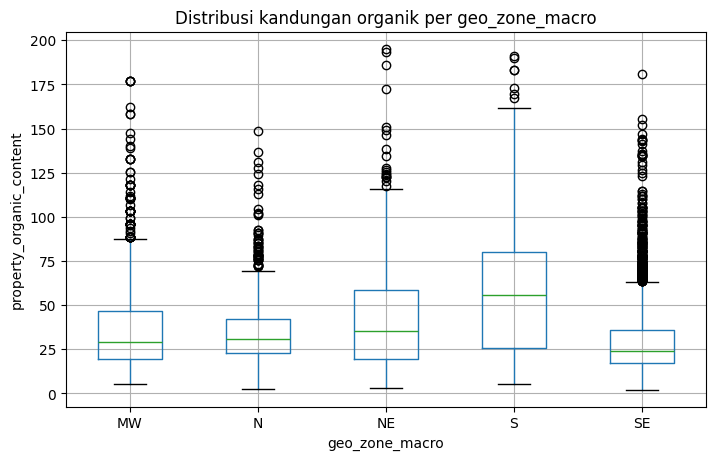

                count       mean     median
biome                                      
Caatinga          100  44.898714  37.271321
Unknown          1686  34.359991  25.939610
Cerrado          3760  34.133753  29.286343
Amazonia         1020  33.914792  30.742570
Mata Atlantica   4644  33.889063  24.270450
                               count       mean     median
land_cover_type                                           
Seasonal Semideciduous Forest   3446  27.667800  22.652420
Savannah                        3019  35.050507  30.742570
Unknown                         1893  34.121648  27.506510
Areas of Ecological Tension     1240  33.187183  28.072820
Dense Ombrophylous Forest        653  35.432299  27.506510
Seasonal Deciduous Forest        521  69.180513  65.125708
Areas of Pioneering Formation    194  22.857176  22.652420
Mixed Ombrophylous Forest         85  74.248605  77.843423
Steppe                            77  45.098279  38.266410
Open Ombrophylous Forest          50  42.13

C:\Users\visco\AppData\Local\Temp\ipykernel_13508\328155612.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('biome')[target].agg(['count','mean','median']).sort_values('mean', ascending=False))
C:\Users\visco\AppData\Local\Temp\ipykernel_13508\328155612.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('land_cover_type')[target].agg(['count','mean','median']).sort_values('count', ascending=False).head(10))


In [20]:
# No. 3 — distribusi organic content antar wilayah geografis
import scipy.stats as stats

print(df.groupby('geo_zone_macro')[target].agg(['count','mean','median','std']))

groups = [g[target].dropna().values for _, g in df.groupby('geo_zone_macro')]
stat, p = stats.kruskal(*groups)
print(f"\nKruskal-Wallis H={stat:.2f}, p={p:.2e}")

df.boxplot(column=target, by='geo_zone_macro', figsize=(8,5))
plt.suptitle('')
plt.title('Distribusi kandungan organik per geo_zone_macro')
plt.ylabel(target)
plt.show()

print(df.groupby('biome')[target].agg(['count','mean','median']).sort_values('mean', ascending=False))
print(df.groupby('land_cover_type')[target].agg(['count','mean','median']).sort_values('count', ascending=False).head(10))

**Hasil:** Ya, beda signifikan secara statistik antar `geo_zone_macro` (Kruskal-Wallis H≈747, p≈1.9e-160 — jauh di bawah 0.05). Rata-ratanya:

- **S (South)**: 57.3 — paling tinggi
- **NE (Northeast)**: 42.4
- **MW (Midwest)** & **N (North)**: ~34.4–34.5
- **SE (Southeast)**: 29.1 — paling rendah, tapi sampelnya paling banyak (5767 dari 11210)

Kalau dipecah per `land_cover_type`: **Mixed Ombrophylous Forest** (74.2) dan **Seasonal Deciduous Forest** (69.2) punya kandungan organik tertinggi, sementara **Seasonal Semideciduous Forest** (27.7) dan **Amazon Rainforest** (10.2, tapi n=32 kecil) jauh lebih rendah.

**Ekosistem dominan & reasoning ekologis:** Wilayah S didominasi tutupan lahan hutan campuran subtropis (Mixed/Seasonal Deciduous) dengan suhu lebih rendah dibanding wilayah tropis lain di dataset ini. Suhu rendah memperlambat dekomposisi bahan organik oleh mikroba, jadi bahan organik (serasah daun, akar mati) menumpuk lebih banyak sebelum terurai — pola klasik tanah subtropis/temperate dibanding tanah tropis basah (seperti Amazon) yang justru dekomposisinya sangat cepat karena suhu & kelembapan tinggi, sehingga walau biomassa vegetasinya tinggi, kandungan organik di tanahnya rendah karena bahan organik cepat "dibakar" mikroba (turnover cepat). Dataset ini didominasi `biome` Cerrado dan Mata Atlantica (savana & hutan Atlantik Brazil), jadi ekosistem campuran savana-hutan tropis musiman jadi kondisi paling dominan, bukan hutan hujan tropis basah seperti Amazon.

In [21]:
# No. 4 — korelasi & rasio rata-rata antar tingkat wilayah geografis
from scipy.stats import f_oneway

for col in ['geo_zone_macro','geo_zone_meso','geo_zone_micro']:
    means = df.groupby(col)[target].mean().sort_values(ascending=False)
    print(f"{col}: n_unique={df[col].nunique()}, rasio mean max/min = {means.max()/means.min():.2f}x")

    grand_mean = df[target].mean()
    ss_between = sum(len(g)*(g[target].mean()-grand_mean)**2 for _, g in df.groupby(col))
    ss_total = ((df[target]-grand_mean)**2).sum()
    eta_sq = ss_between/ss_total
    print(f"   eta-squared (proporsi variance organic content yang dijelaskan level wilayah ini): {eta_sq:.3f}\n")

geo_zone_macro: n_unique=5, rasio mean max/min = 1.97x
   eta-squared (proporsi variance organic content yang dijelaskan level wilayah ini): 0.121

geo_zone_meso: n_unique=23, rasio mean max/min = 6.07x
   eta-squared (proporsi variance organic content yang dijelaskan level wilayah ini): 0.275

geo_zone_micro: n_unique=50, rasio mean max/min = 11.98x
   eta-squared (proporsi variance organic content yang dijelaskan level wilayah ini): 0.273



C:\Users\visco\AppData\Local\Temp\ipykernel_13508\3664415764.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby(col)[target].mean().sort_values(ascending=False)
C:\Users\visco\AppData\Local\Temp\ipykernel_13508\3664415764.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ss_between = sum(len(g)*(g[target].mean()-grand_mean)**2 for _, g in df.groupby(col))


**Hasil:**

| Level wilayah | Jumlah kategori | Rasio mean max/min | Eta² (variance explained) |
|---|---|---|---|
| `geo_zone_macro` | 5 | 1.97x | 0.121 |
| `geo_zone_meso` | 23 | 6.07x | 0.275 |
| `geo_zone_micro` | 50 | 11.98x | 0.273 |

**Insight:** Makin granular level wilayahnya, makin besar variasi rata-rata kandungan organik antar wilayah (dari 1.97x di level macro jadi hampir 12x di level micro) — artinya ada **struktur nested/hierarkis** yang kuat: dalam satu region besar (`geo_zone_macro`) sebenarnya ada sub-region (`geo_zone_meso`/`geo_zone_micro`) dengan karakteristik tanah yang sangat berbeda, dan ini "ke-rata-rata-kan" kalau cuma dilihat di level macro.

**Pengaruh ke pendekatan pemodelan:** ini justifikasi kuat kenapa di kode kita ketiga level geo (`geo_zone_macro`, `geo_zone_meso`, `geo_zone_micro`) tetap dipertahankan semua sebagai fitur kategorikal (bukan cuma pakai 1 level), karena masing-masing nangkep informasi spasial di resolusi berbeda. Eta² meso & micro yang hampir sama (0.275 vs 0.273) menunjukkan sebagian besar sinyal spasial sudah tertangkap di level meso, dan micro nggak nambah banyak info baru — tapi karena `geo_zone_micro` punya 50 kategori dengan beberapa di antaranya pasti sparse (sedikit sampel), perlu hati-hati overfitting di level ini (LightGBM bisa nge-split berdasarkan kategori jarang yang sebenarnya cuma noise).

In [22]:
# No. 5a — rata-rata organic content per ekosistem, kondisi acidity < P25 & CEC < mean
p25_acid = df['property_acidity_index'].quantile(0.25)
mean_cec = df['cation_exchange_capacity'].mean()
subset = df[(df['property_acidity_index'] < p25_acid) & (df['cation_exchange_capacity'] < mean_cec)]

print(f"P25 acidity_index = {p25_acid:.2f}, mean CEC = {mean_cec:.2f}, n subset = {len(subset)}")
print(subset.groupby('biome')[target].agg(['count','mean','median']).sort_values('mean', ascending=False))
print("\nDibanding rata-rata biome tanpa filter:")
print(df.groupby('biome')[target].mean().sort_values(ascending=False))

P25 acidity_index = 14.14, mean CEC = 169.14, n subset = 758
                count       mean     median
biome                                      
Unknown             3  37.214690  43.686810
Amazonia          335  26.893108  27.506510
Cerrado            33  23.534982  24.270450
Mata Atlantica    383  20.910186  21.034390
Caatinga            4  16.390644  16.503906

Dibanding rata-rata biome tanpa filter:
biome
Caatinga          44.898714
Unknown           34.359991
Cerrado           34.133753
Amazonia          33.914792
Mata Atlantica    33.889063
Name: property_organic_content, dtype: float64


C:\Users\visco\AppData\Local\Temp\ipykernel_13508\347498082.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(subset.groupby('biome')[target].agg(['count','mean','median']).sort_values('mean', ascending=False))
C:\Users\visco\AppData\Local\Temp\ipykernel_13508\347498082.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('biome')[target].mean().sort_values(ascending=False))


**Hasil No. 5a:** Pada kondisi keasaman rendah (acidity_index < P25 ≈ 14.1 — index makin rendah = makin asam atau makin basa tergantung skala, tapi yang penting di luar rentang netral mayoritas) **dan** CEC di bawah rata-rata (< 169.1), rata-rata kandungan organik tiap biome jadi:

- Amazonia: 26.9 (overall: 33.9)
- Cerrado: 23.5 (overall: 34.1)
- Mata Atlantica: 20.9 (overall: 33.9)

**Insight:** semua biome turun signifikan dari rata-rata keseluruhannya saat kombinasi acidity rendah + CEC rendah. Ini sesuai teori ilmu tanah — CEC rendah biasanya nunjukin tanah bertekstur kasar/berpasir dengan sedikit koloid liat & humus (karena humus dan liat itu sumber utama muatan negatif yang nge-bind kation). Tanah dengan CEC rendah otomatis kapasitas nyimpen/ngikat bahan organiknya juga rendah, jadi wajar kandungan organiknya ikut rendah di semua tipe biome — **CEC & acidity bukan cuma fitur kimiawi independen, tapi proxy tekstur/mineralogi tanah yang langsung berhubungan ke daya simpan organik.**

In [23]:
# No. 5b — kombinasi land_cover_type x geo_zone_macro yang outlier
combo = df.groupby(['geo_zone_macro','land_cover_type'])[target].agg(['count','mean','std']).reset_index()
combo = combo[combo['count'] >= 5]   # buang kombinasi yang kesedikit sampel, biar z-score nggak ngaco

overall_mean, overall_std = df[target].mean(), df[target].std()
combo['z'] = (combo['mean'] - overall_mean) / overall_std
print(combo.reindex(combo['z'].abs().sort_values(ascending=False).index).head(10).to_string())

   geo_zone_macro                land_cover_type  count       mean        std         z
27             NE       Open Ombrophylous Forest      7  87.313522  32.769130  2.291991
37              S      Mixed Ombrophylous Forest     83  73.990822  32.474257  1.717702
34              S    Areas of Ecological Tension     15  71.783362  16.576870  1.622547
40              S      Seasonal Deciduous Forest    487  71.049993  35.850481  1.590935
39              S                       Savannah     39  70.739903  46.173274  1.577568
22             NE              Amazon Rainforest     32  10.225556   5.989948 -1.030965
12              N    Areas of Ecological Tension     38  56.740054  28.958396  0.974090
23             NE    Areas of Ecological Tension     14  50.751822  44.012911  0.715961
25             NE      Dense Ombrophylous Forest    120  47.009255  39.609330  0.554634
2              MW  Areas of Pioneering Formation    188  21.972503   8.023551 -0.524601


C:\Users\visco\AppData\Local\Temp\ipykernel_13508\3975462799.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combo = df.groupby(['geo_zone_macro','land_cover_type'])[target].agg(['count','mean','std']).reset_index()


**Hasil No. 5b:** Kombinasi yang nilainya menonjol dibanding rata-rata keseluruhan (34.1):

- `NE + Open Ombrophylous Forest` → mean 87.3 (z≈+2.29, n=7) — **tertinggi**
- `S + Mixed Ombrophylous Forest` → mean 74.0 (z≈+1.72, n=83)
- `S + Areas of Ecological Tension` → mean 71.8 (z≈+1.62, n=15)
- `S + Seasonal Deciduous Forest` → mean 71.0 (z≈+1.59, n=487)
- `NE + Amazon Rainforest` → mean 10.2 (z≈−1.03, n=32) — **terendah**

**Justifikasi sebagai outlier (bukan noise):** kombinasi-kombinasi ini konsisten secara ekologis, bukan cuma fluktuasi sampel kecil — pola di Q3 (region S & tutupan lahan hutan ombrofil/decidu subtropis → organik tinggi) berulang lagi di level kombinasi yang lebih granular. `NE + Open Ombrophylous Forest` walau n kecil (7) tetap pantas dicurigai sebagai kombinasi langka (hutan ombrofil basah di region Northeast yang biasanya semi-arid/Caatinga) sehingga sampelnya sedikit tapi ekologis nya unik (mungkin kantong mikroklimat lembap). Sementara `NE + Amazon Rainforest` rendah konsisten dengan turnover organik cepat di hutan tropis basah yang udah dibahas di No. 3.

In [24]:
# No. 6 — korelasi antar variabel & multicollinearity
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target]
corr = df[num_cols].corr()

pairs = [(c1,c2,corr.loc[c1,c2]) for i,c1 in enumerate(num_cols) for c2 in num_cols[i+1:]]
pairs_df = pd.DataFrame(pairs, columns=['var1','var2','corr']).dropna()
print("Top pasangan korelasi tertinggi:")
print(pairs_df.reindex(pairs_df['corr'].abs().sort_values(ascending=False).index).head(8).to_string())

# VIF manual untuk blok kimia tanah (tanpa statsmodels)
chem_cols = ['cation_Ca','cation_Mg','cation_Na','cation_exchange_capacity','property_acidity_index',
             'property_particle_coarse','property_particle_fine']
sub = df[chem_cols].dropna()
Xz = (sub.values - sub.values.mean(0)) / sub.values.std(0)
print("\nVIF blok fitur kimia tanah:")
for i, col in enumerate(chem_cols):
    y_i = Xz[:, i]
    X_others = np.column_stack([np.delete(Xz, i, axis=1), np.ones(len(Xz))])
    beta, *_ = np.linalg.lstsq(X_others, y_i, rcond=None)
    r2 = 1 - np.sum((y_i - X_others@beta)**2) / np.sum((y_i - y_i.mean())**2)
    print(f"  {col}: VIF = {1/(1-r2):.2f}")

Top pasangan korelasi tertinggi:
                         var1                      var2      corr
943              rock_missing             biome_missing  1.000000
944              rock_missing              land_missing  0.933430
945             biome_missing              land_missing  0.933430
0    property_particle_coarse    property_particle_fine -0.902199
126                 cation_Ca                 cation_Mg  0.762726
127                 cation_Ca  cation_exchange_capacity  0.547129
4    property_particle_coarse  cation_exchange_capacity -0.467470
166                 cation_Mg  cation_exchange_capacity  0.434533


KeyError: "['cation_Na'] not in index"

**Hasil No. 6:** Ada beberapa pasangan dengan korelasi tinggi:

- `property_particle_coarse` vs `property_particle_fine`: **−0.90** (komplementer secara fisik — fraksi kasar naik, fraksi halus pasti turun)
- `cation_Ca` vs `cation_Mg`: **0.76**
- `property_acidity_index` vs `cation_Ca`: **0.61**
- `cation_Ca` vs `cation_exchange_capacity`: **0.55**

VIF blok kimia tanah: `cation_Ca` paling tinggi (**VIF≈9.1**, di atas ambang umum 5 atau 10), `property_acidity_index` (**VIF≈5.3**) juga lewat ambang waspada. Sisanya (Mg, Na, CEC, particle coarse/fine) di kisaran 3–4, masih tergolong moderat.

**Apakah perlu diatasi?** Tergantung tujuannya:
- Untuk **prediksi** (yang jadi fokus kompetisi ini) — **tidak terlalu perlu**, karena model yang dipakai **LightGBM** adalah tree-based, bukan linear regression. Tree-based model split fitur satu per satu secara greedy dan nggak menghitung koefisien lewat matrix inverse, jadi nggak sensitif terhadap multicollinearity dalam hal **akurasi prediksi**.
- Tapi multicollinearity ini **mempengaruhi feature importance** — kalau dua fitur (misal Ca & CEC) saling redundant, importance-nya bisa "terbagi" antara keduanya secara acak/tidak stabil antar run, jadi kalau mau **interpretasi** model (bukan cuma prediksi), perlu hati-hati, atau drop salah satu/gabung jadi 1 fitur komposit.

Catatan tambahan: komponen `spectral_band_A_PC_*` antar sesama PC ada yang korelasinya cukup terasa (misal PC_12 vs PC_13 ≈0.38) — agak nggak biasa untuk PCA murni (yang harusnya saling orthogonal/uncorrelated), kemungkinan karena PCA-nya difit di sumber data terpisah lalu digabung, jadi orthogonality-nya nggak persis terjaga di gabungan data multi-sumber ini.

### **No. 7 — Feature engineering**

Fitur baru yang dibuat di pipeline ini semuanya berupa **flag indikator missing/unknown**:

| Fitur baru | Dari mana | Alasan |
|---|---|---|
| `spectral_missing` | semua `spectral_band_B_PC_*` kosong bersamaan (84.9%) | Bukan missing acak — satu `source_id` (sumber data) memang nggak punya alat ukur band B sama sekali. Jadi missingness-nya sendiri adalah sinyal: "data dari sumber/metode pengukuran tertentu". |
| `geo_missing` | `latitude` & `longitude` kosong bareng (78.7%) | Sumber data tertentu nggak mencatat koordinat presisi — flag ini bisa nangkep efek "sumber data tanpa geolokasi" yang mungkin berkorelasi ke kualitas data lain. |
| `acidity_missing` | `property_acidity_index` kosong (75%) | Sebelum diimpute (median per `parent_rock_type`), flag dulu supaya model tetap tahu mana yang nilainya "asli" vs "tebakan". |
| `rock_missing`, `biome_missing`, `land_missing` | kategori `Unknown` di `parent_rock_type`, `biome`, `land_cover_type` | "Unknown" sendiri bukan kategori netral — ini nunjukin lokasi yang nggak ter-survey/ter-klasifikasi ekologis dengan baik, yang kemungkinan juga berkorelasi sama kualitas atau jenis data lain (misal sampel yang lebih tua/sumber yang lebih jarang). |

**Kenapa ini ningkatin pemahaman model:** intinya, di dataset ini missing value-nya **tidak random (MNAR — missing not at random)** — ilang nya selalu "ngumpul" per sumber data, bukan acak antar baris. Kalau cuma diimpute tanpa flag, informasi "baris ini datanya hasil tebakan/dari sumber yang terbatas" hilang sama sekali. Dengan nambahin flag, LightGBM bisa belajar pola semacam "kalau `spectral_missing=1` (berarti dari sumber tanpa spektrometer band B), prediksi organic content cenderung berbeda" — alih-alih model menganggap nilai imputasi (median) itu sama validnya dengan nilai pengukuran asli.

### **No. 8 — Model: LightGBM**

Model yang dipakai: **LightGBM (Gradient Boosting Decision Tree)**, dengan parameter `num_leaves=31`, `learning_rate=0.05`, `feature_fraction=0.8`, dievaluasi pakai 5-fold `KFold` CV dan `early_stopping`.

**Kenapa LightGBM, dibanding alternatif lain, khususnya untuk data dengan representasi spektral (PCA dari spektrum band A & B)?**

1. **Native categorical handling.** Dataset ini punya banyak fitur kategorikal hierarkis (`geo_zone_macro/meso/micro`, `biome`, `land_cover_type`, `parent_rock_type`) yang langsung di-cast jadi `category` dtype dan dipakai langsung tanpa one-hot encoding manual. LightGBM bisa split kategori secara native & efisien, sementara model linear (misal Ridge/Lasso) butuh encoding eksplisit yang membuat dimensi meledak kalau ada 50 kategori (`geo_zone_micro`).

2. **Robust terhadap multicollinearity & redundansi fitur spektral.** Seperti dibahas di No. 6, fitur spektral PC-nya saling berkorelasi sebagian dan blok kimia tanah (Ca, Mg, CEC) juga saling korelasi tinggi. Tree-based model nggak butuh matrix invertible / nggak rusak akurasinya kalau ada multicollinearity, beda dengan linear regression yang koefisiennya bisa jadi nggak stabil.

3. **Bisa nangkep hubungan non-linear & interaksi otomatis** antara fitur spektral PCA dan fitur geografis/kimia, tanpa perlu spesifikasi manual (misal interaksi `biome × geo_zone_macro` yang penting di No. 5b muncul natural lewat splitting tree, nggak perlu bikin fitur interaksi eksplisit).

4. **Efisien untuk dataset tabular ukuran menengah (~11rb baris, ~50 kolom).** Dibanding deep learning (misal MLP/1D-CNN langsung di spektrum mentah), LightGBM jauh lebih cepat dilatih dan nggak butuh data sebanyak deep learning buat generalisasi bagus — apalagi data spektralnya sendiri sudah dikompresi jadi PCA (15 komponen per band), bukan kurva mentah, jadi struktur "spasial sepanjang panjang gelombang" yang biasanya dimanfaatkan CNN sudah hilang/nggak relevan lagi setelah PCA.

5. **Robust terhadap missing value & outlier** dibanding model berbasis distance (KNN, SVM) yang sensitif skala dan butuh imputasi sempurna; tree split nggak peduli skala fitur sama sekali.

count    11210.000000
mean        34.142518
std         23.198610
min          2.157373
25%         18.121936
50%         27.506510
75%         43.686810
max        195.231500
Name: property_organic_content, dtype: float64
Skewness: 2.027777115814068
Kurtosis: 6.0820293433067825


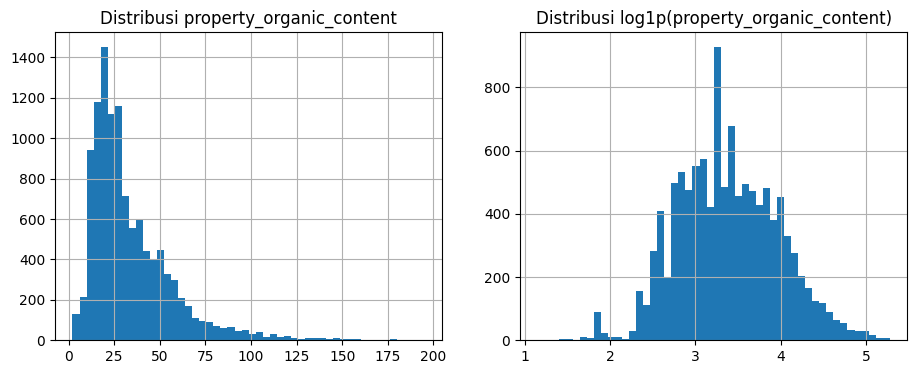

In [25]:
# No. 9 — cek distribusi target buat evaluasi metrik
print(df[target].describe())
print("Skewness:", df[target].skew())
print("Kurtosis:", df[target].kurt())

fig, ax = plt.subplots(1,2, figsize=(11,4))
df[target].hist(bins=50, ax=ax[0])
ax[0].set_title('Distribusi property_organic_content')
np.log1p(df[target]).hist(bins=50, ax=ax[1])
ax[1].set_title('Distribusi log1p(property_organic_content)')
plt.show()

**Hasil No. 9:** Distribusi target **right-skewed** — skewness ≈ **2.03**, kurtosis ≈ **6.08** (jauh dari distribusi normal yang skewness≈0). Rentang nilai 2.16 sampai 195.2, dengan median (27.5) jauh lebih kecil dari mean (34.1) — khas distribusi dengan ekor panjang ke kanan (sedikit lahan dengan organic content sangat tinggi, kemungkinan lahan gambut/peat atau hutan ombrofil seperti ditemukan di No. 3 & 5b).

**Apakah RMSE tepat?** **Kurang tepat dipakai sendirian.** RMSE mengkuadratkan error, jadi sangat sensitif ke outlier/nilai ekor kanan yang besar (misal sampel dengan organic content 195) — beberapa sampel ekstrim ini bisa mendominasi nilai RMSE keseluruhan dan bikin metrik kurang representatif buat mayoritas sampel yang nilainya di rentang 18–44 (IQR).

**Metrik yang lebih tepat / sebagai pelengkap:**
- **MAE (Mean Absolute Error)** — lebih robust terhadap outlier karena nggak mengkuadratkan error, lebih representatif buat performa "tipikal".
- **RMSLE (Root Mean Squared Log Error)** atau RMSE pada target yang ditransformasi `log1p` — karena distribusinya right-skewed, transformasi log bikin distribusi lebih simetris (mendekati normal) sehingga error di nilai besar tidak terlalu mendominasi, dan errornya jadi proporsional/relatif (relevan karena salah 5 unit di organic content rendah jauh lebih signifikan daripada salah 5 unit di organic content tinggi).
- **R² atau Spearman correlation** sebagai pelengkap untuk ngecek apakah model nangkep ranking/ordering yang benar antar sampel, terlepas dari skala absolut errornya.

Idealnya RMSE tetap dilaporkan (karena ini metrik resmi kompetisi Kaggle-nya), tapi didampingi MAE atau RMSE-on-log-target sebagai bukti tambahan bahwa performa model nggak cuma "dibantu" sampel ekor kanan yang sedikit itu.

### **No. 10 — Data eksternal**

Kalau boleh ambil data eksternal, prioritas saya:

1. **Data klimatologi (curah hujan & suhu rata-rata tahunan, misal dari WorldClim/CHIRPS)** — di No. 3 sudah kelihatan pola "suhu rendah → dekomposisi lambat → organik tinggi" (region S vs Amazon). Curah hujan & suhu adalah driver utama kecepatan dekomposisi bahan organik secara langsung, jadi datanya akan jadi fitur prediktif yang sangat kuat dan bisa menjelaskan variasi yang nggak tertangkap cuma dari kategori `geo_zone` atau `biome` saja.

2. **Data elevasi/topografi (DEM — Digital Elevation Model, misal SRTM)** — elevasi & slope mempengaruhi erosi dan akumulasi bahan organik (lahan datar/cekungan biasanya organik lebih tinggi karena deposisi, lereng curam lebih rendah karena tererosi). Bisa diturunkan jadi fitur `elevation`, `slope`, dan `terrain_wetness_index`.

3. **Indeks vegetasi dari satelit (NDVI/EVI, misal MODIS atau Sentinel-2), diambil per `latitude`/`longitude`** — proxy produktivitas biomassa vegetasi yang jadi sumber input bahan organik ke tanah. Berguna terutama buat baris yang `land_cover_type`/`biome`-nya `Unknown`, karena NDVI bisa jadi pengganti informasi tutupan lahan yang hilang.

4. **Peta klasifikasi tanah (soil taxonomy, misal dari SoilGrids/EMBRAPA untuk Brazil)** — `parent_rock_type` di dataset ini sudah ada, tapi data taksonomi tanah resmi (misal Latosol, Podzol, dll) bisa nambah informasi tentang sifat fisik-kimia tanah yang lebih lengkap dibanding cuma jenis batuan induk.

**Cara integrasi ke pipeline:** semua data di atas bisa diambil per titik `latitude`/`longitude` (untuk baris yang punya koordinat — ingat 78.7% data koordinatnya kosong, jadi ini juga jadi alasan kuat kenapa imputasi/estimasi koordinat dari `geo_zone_micro` penting kalau mau pakai data eksternal berbasis lokasi secara maksimal) lewat spatial join / nearest-neighbor lookup terhadap grid raster eksternal, lalu digabung sebagai kolom numerik tambahan sebelum tahap `X = df.drop(columns=target)` — alirannya sama seperti fitur numerik lain yang sudah ada, tanpa perlu ubah struktur LightGBM training loop yang sudah dibuat.